# Yhack Prediction Market Dashboard Lab

## 1. Problem Statement

This notebook follows an **asset-first trading architecture**.

We are **not** directly trading binary Polymarket contracts such as "Will Bitcoin reach price X?".
Instead:

- we trade the underlying crypto asset such as `BTC`, `ETH`, or `SOL`
- we use financial market data as the main trading engine
- we use Polymarket as an **information, confidence, and caution layer**
- Polymarket helps us decide whether to:
  - take the trade
  - reduce size
  - hold off
  - avoid entirely

## Goal

Build a research notebook that simulates crypto trading decisions using:

1. **underlying market data** for direction and trade setup
2. **relevant Polymarket questions** for confirmation and risk context
3. a **fusion layer** that converts technical strength and prediction-market context into:
   - confidence score
   - caution zone
   - position size recommendation

## Architecture Order

This notebook is implemented in the exact agreed order:

1. Problem statement
2. Inputs
3. Underlying market data
4. Polymarket data pull
5. Question tagging
6. Polymarket aggregation
7. Fusion logic
8. Decision dashboard
9. Scenario analysis
10. Backtest comparison


## 2. Inputs

These inputs control the asset-first experiment. The traded object is the crypto asset, while Polymarket markets are pulled and summarized as supporting evidence.


In [1]:
import json
import os
import sys
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')

for candidate in [Path.cwd(), Path.cwd() / 'Yhack']:
    candidate_str = str(candidate.resolve())
    if candidate.exists() and candidate_str not in sys.path:
        sys.path.append(candidate_str)

from polymarket_config import get_polymarket_config, redacted_polymarket_config

try:
    from py_clob_client.client import ClobClient
except Exception:
    ClobClient = None

asset = 'BTC-USD'
asset_label = 'BTC'
benchmark_asset = 'SPY'
start_date = '2024-01-01'
end_date = '2025-03-01'
interval = '1d'
market_data_mode = 'auto'

polymarket_env_path = Path.cwd() / 'Yhack' / '.env'
polymarket_use_live = True
polymarket_market_limit = 120
polymarket_search_terms = {
    'BTC': ['bitcoin', 'btc', 'crypto reserve', 'bitcoin reserve', 'bitcoin etf'],
    'ETH': ['ethereum', 'eth', 'ether etf'],
    'SOL': ['solana', 'sol', 'sol etf'],
}

technical_long_threshold = 0.25
technical_short_threshold = -0.25
pm_confirmation_threshold = 0.05
confidence_trade_threshold = 35
avoid_threshold = 75
subjective_prob_buffer = 0.05

polymarket_config = get_polymarket_config(polymarket_env_path)
print({'asset': asset, 'asset_label': asset_label, 'benchmark_asset': benchmark_asset, 'start_date': start_date, 'end_date': end_date, 'interval': interval, 'market_data_mode': market_data_mode})
print(redacted_polymarket_config(polymarket_env_path))


{'asset': 'BTC-USD', 'asset_label': 'BTC', 'benchmark_asset': 'SPY', 'start_date': '2024-01-01', 'end_date': '2025-03-01', 'interval': '1d', 'market_data_mode': 'auto'}
{'env_path': '/Users/sabyasachi/Library/CloudStorage/OneDrive-rbionline/golden jubilee application/mission 2025/final college selection/housing/ds_project/rentwise-project/Yhack/Yhack/.env', 'gamma_host': 'https://gamma-api.polymarket.com', 'clob_host': 'https://clob.polymarket.com', 'data_host': 'https://data-api.polymarket.com', 'request_timeout': 20, 'chain_id': 137, 'has_private_key': False, 'has_proxy_address': False, 'has_api_key': False, 'has_secret': False, 'has_passphrase': False}


## 3. Underlying Market Data

This section is the main trading engine. It uses normal financial market data for the selected crypto asset and produces the base technical signal.


Market source: Yahoo Finance


Price,Close,Return_1D,RSI,MACD_Hist,Volatility_20D,Drawdown,TechnicalScore,BaseDirection,TechnicalConfidence
Date,,,,,,,,,
2025-02-17,95773.382812,-0.004176,29.493117,-192.547596,0.290420,-0.097723,-0.5,Short,50.0
2025-02-18,95539.546875,-0.002442,38.821869,-199.169797,0.273830,-0.099926,-0.7,Short,70.0
2025-02-19,96635.609375,0.011472,50.098151,-114.956750,0.274900,-0.089600,-0.7,Short,70.0
2025-02-20,98333.937500,0.017575,57.284130,60.472678,0.275836,-0.073600,0.5,Long,50.0
2025-02-21,96125.546875,-0.022458,48.568234,34.422973,0.280494,-0.094405,-0.2,Flat,20.0
2025-02-22,96577.757812,0.004704,50.328684,53.170539,0.261565,-0.090145,-0.2,Flat,20.0
2025-02-23,96273.921875,-0.003146,49.235085,50.643056,0.219900,-0.093007,-0.2,Flat,20.0
2025-02-24,91418.171875,-0.050437,33.907471,-255.694668,0.256706,-0.138753,-0.8,Short,80.0
2025-02-25,88736.171875,-0.029338,32.199769,-597.089608,0.271533,-0.164020,-0.8,Short,80.0


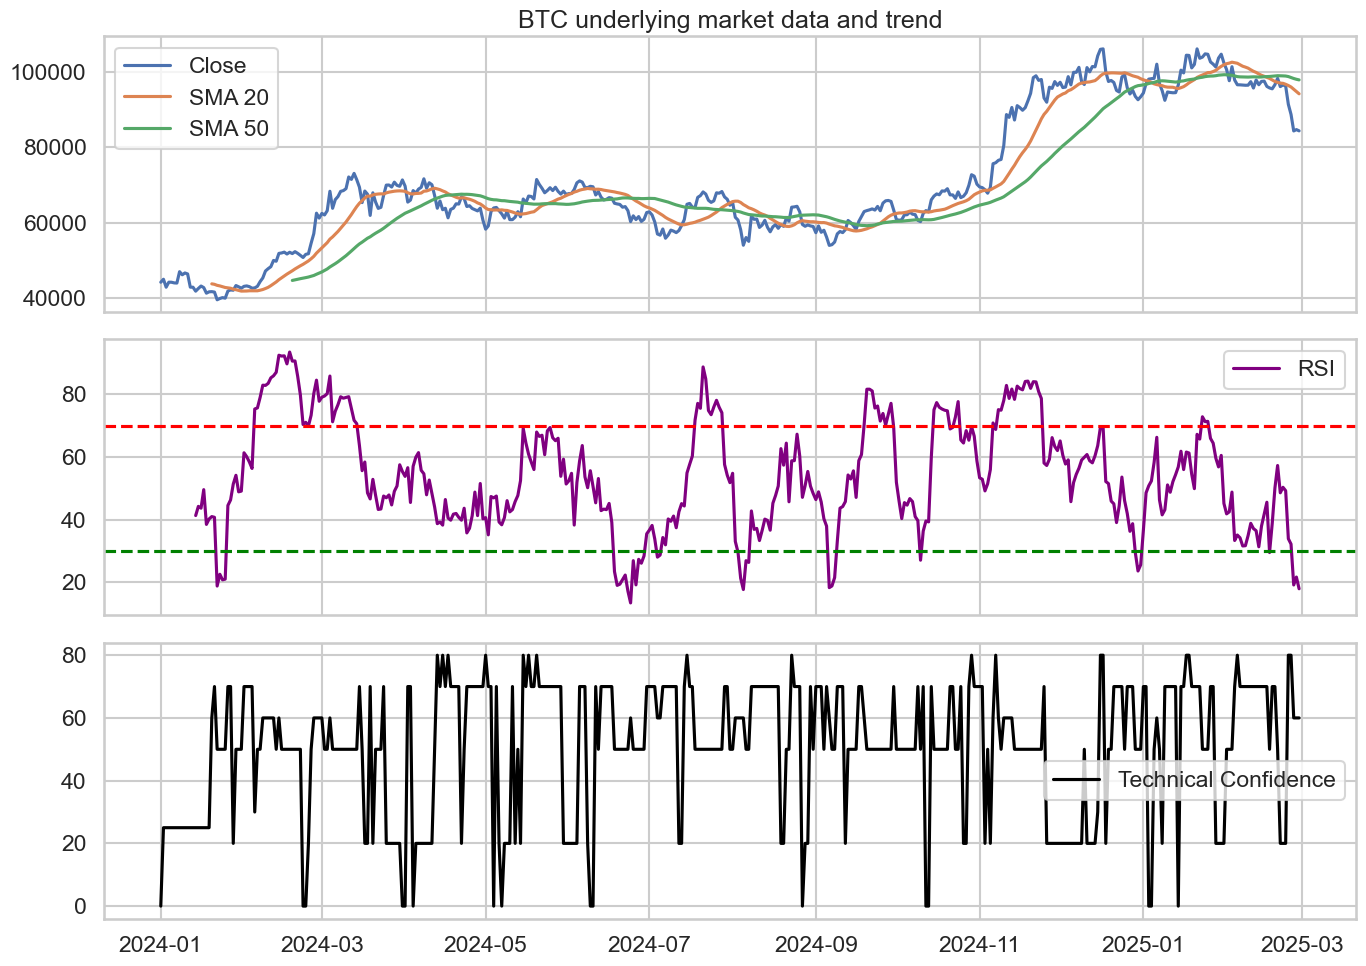

In [2]:
def generate_synthetic_data(ticker, start_date, end_date, interval):
    start_ts = pd.to_datetime(start_date)
    end_ts = pd.to_datetime(end_date)
    freq_map = {'1h': 'H', '1d': 'B', '1wk': 'W-FRI', '1mo': 'MS', '1y': 'YS'}
    freq = freq_map.get(interval, 'B')
    idx = pd.date_range(start_ts, end_ts, freq=freq)
    if len(idx) < 120:
        idx = pd.date_range(start_ts, periods=220, freq='B')

    seed = sum(ord(ch) for ch in ticker) % (2**32 - 1)
    rng = np.random.default_rng(seed)
    drift = 0.0005 + (seed % 13) / 100000
    vol = 0.018 + (seed % 9) / 1000
    shocks = rng.normal(drift, vol, len(idx))
    close = 100 * np.exp(np.cumsum(shocks))
    open_ = np.concatenate([[close[0]], close[:-1]]) * (1 + rng.normal(0, 0.003, len(idx)))
    high = np.maximum(open_, close) * (1 + rng.uniform(0.001, 0.018, len(idx)))
    low = np.minimum(open_, close) * (1 - rng.uniform(0.001, 0.018, len(idx)))
    volume = rng.integers(1_000_000, 8_000_000, len(idx))
    synthetic = pd.DataFrame({'Open': open_, 'High': high, 'Low': low, 'Close': close, 'Adj Close': close, 'Volume': volume}, index=idx)
    synthetic.index.name = 'Date'
    return synthetic


def get_market_data(ticker, start_date, end_date, interval, data_mode='auto'):
    data = pd.DataFrame()
    source = 'Synthetic Fallback'
    if data_mode.lower() in {'auto', 'live'}:
        try:
            data = yf.download(ticker, start=start_date, end=end_date, interval=interval, progress=False, auto_adjust=False, threads=False, timeout=6)
        except Exception:
            data = pd.DataFrame()
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    required_cols = {'Open', 'High', 'Low', 'Close'}
    if not data.empty and required_cols.issubset(set(data.columns)):
        source = 'Yahoo Finance'
        return data.sort_index(), source
    return generate_synthetic_data(ticker, start_date, end_date, interval).sort_index(), source


def build_feature_lab(data, rsi_window=14, fast_window=12, slow_window=26, trend_window=20, long_trend_window=50, vol_window=20):
    df = data.copy()
    close = df['Close']
    high = df['High']
    low = df['Low']
    volume = df['Volume'] if 'Volume' in df.columns else pd.Series(index=df.index, dtype=float)

    df['Return_1D'] = close.pct_change()
    df['Return_5D'] = close.pct_change(5)
    df['Return_20D'] = close.pct_change(20)
    df['LogReturn'] = np.log(close / close.shift(1))
    df['SMA_20'] = close.rolling(trend_window).mean()
    df['SMA_50'] = close.rolling(long_trend_window).mean()
    df['EMA_12'] = close.ewm(span=fast_window, adjust=False).mean()
    df['EMA_26'] = close.ewm(span=slow_window, adjust=False).mean()
    df['Momentum_20'] = close / close.shift(20) - 1

    delta = close.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.rolling(window=rsi_window).mean()
    avg_loss = loss.rolling(window=rsi_window).mean().replace(0, 1e-10)
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))

    df['MACD'] = df['EMA_12'] - df['EMA_26']
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']

    rolling_mean = close.rolling(trend_window).mean()
    rolling_std = close.rolling(trend_window).std()
    df['BB_Upper'] = rolling_mean + 2 * rolling_std
    df['BB_Lower'] = rolling_mean - 2 * rolling_std
    df['BB_Z'] = (close - rolling_mean) / rolling_std.replace(0, np.nan)
    df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / rolling_mean.replace(0, np.nan)

    true_range = pd.concat([high - low, (high - close.shift(1)).abs(), (low - close.shift(1)).abs()], axis=1).max(axis=1)
    df['ATR_14'] = true_range.rolling(14).mean()
    df['RangePct'] = (high - low) / close.replace(0, np.nan)
    df['Volatility_20D'] = df['LogReturn'].rolling(vol_window).std() * np.sqrt(252)
    df['Drawdown'] = close / close.cummax() - 1
    df['Volume_Z'] = (volume - volume.rolling(20).mean()) / volume.rolling(20).std().replace(0, np.nan)

    df['RSI_Signal'] = np.select([df['RSI'] < 30, df['RSI'] > 70], [1, -1], default=0)
    df['Trend_Signal'] = np.select([close > df['SMA_20'], close < df['SMA_20']], [1, -1], default=0)
    df['MACD_Signal_Flag'] = np.select([df['MACD_Hist'] > 0, df['MACD_Hist'] < 0], [1, -1], default=0)
    df['Breakout_Signal'] = np.select([close > df['BB_Upper'], close < df['BB_Lower']], [1, -1], default=0)

    df['TechnicalScore'] = (
        0.35 * df['Trend_Signal']
        + 0.25 * df['MACD_Signal_Flag']
        + 0.20 * df['RSI_Signal']
        + 0.10 * df['Breakout_Signal']
        + 0.10 * np.sign(df['Momentum_20'].fillna(0))
    )
    df['BaseDirection'] = np.select([df['TechnicalScore'] >= technical_long_threshold, df['TechnicalScore'] <= technical_short_threshold], ['Long', 'Short'], default='Flat')
    df['TechnicalConfidence'] = 100 * np.clip(df['TechnicalScore'].abs(), 0, 1)
    return df


market_data, market_source = get_market_data(asset, start_date, end_date, interval, market_data_mode)
feature_data = build_feature_lab(market_data)
print('Market source:', market_source)
display(feature_data[['Close', 'Return_1D', 'RSI', 'MACD_Hist', 'Volatility_20D', 'Drawdown', 'TechnicalScore', 'BaseDirection', 'TechnicalConfidence']].tail(12))

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(feature_data.index, feature_data['Close'], label='Close')
axes[0].plot(feature_data.index, feature_data['SMA_20'], label='SMA 20')
axes[0].plot(feature_data.index, feature_data['SMA_50'], label='SMA 50')
axes[0].legend()
axes[0].set_title(f'{asset_label} underlying market data and trend')
axes[1].plot(feature_data.index, feature_data['RSI'], label='RSI', color='purple')
axes[1].axhline(30, linestyle='--', color='green')
axes[1].axhline(70, linestyle='--', color='red')
axes[1].legend()
axes[2].plot(feature_data.index, feature_data['TechnicalConfidence'], label='Technical Confidence', color='black')
axes[2].legend()
plt.tight_layout()
plt.show()


## 4. Polymarket Data Pull

This section fetches real Polymarket markets related to the selected asset. These markets are not traded directly. They are treated as event and sentiment inputs.


In [3]:
def parse_token_ids(raw_value):
    if raw_value is None or (isinstance(raw_value, float) and np.isnan(raw_value)):
        return []
    if isinstance(raw_value, list):
        return [str(x) for x in raw_value if str(x).strip()]
    if isinstance(raw_value, str):
        text = raw_value.strip()
        if not text:
            return []
        try:
            parsed = json.loads(text)
            if isinstance(parsed, list):
                return [str(x) for x in parsed if str(x).strip()]
        except Exception:
            pass
        if ',' in text:
            return [part.strip() for part in text.split(',') if part.strip()]
        return [text]
    return [str(raw_value)]


def safe_json_request(method, url, timeout=20, **kwargs):
    response = requests.request(method, url, timeout=timeout, **kwargs)
    response.raise_for_status()
    return response.json()


def fetch_gamma_markets(config, limit=100):
    params = {'limit': limit, 'active': 'true', 'closed': 'false'}
    data = safe_json_request('GET', f"{config['gamma_host'].rstrip('/')}/markets", params=params, timeout=config['request_timeout'])
    if isinstance(data, dict):
        data = data.get('markets', data.get('data', []))
    return pd.DataFrame(data)


def normalize_book_levels(levels):
    out = []
    for level in levels or []:
        price = getattr(level, 'price', None)
        size = getattr(level, 'size', None)
        if isinstance(level, dict):
            price = level.get('price', price)
            size = level.get('size', size)
        if price is not None:
            out.append({'price': float(price), 'size': float(size) if size is not None else np.nan})
    return out


def build_clob_client(config):
    if ClobClient is None:
        return None
    try:
        return ClobClient(config['clob_host'])
    except Exception:
        return None


def fetch_order_book_snapshot(token_id, config, client=None):
    if not token_id:
        return {'bids': [], 'asks': [], 'source': 'no_token'}
    if client is not None:
        try:
            book = client.get_order_book(token_id)
            return {'bids': normalize_book_levels(getattr(book, 'bids', [])), 'asks': normalize_book_levels(getattr(book, 'asks', [])), 'source': 'py_clob_client'}
        except Exception:
            pass

    host = config['clob_host'].rstrip('/')
    attempts = [
        ('GET', f'{host}/book', {'params': {'token_id': token_id}}),
        ('GET', f'{host}/book', {'params': {'asset_id': token_id}}),
        ('POST', f'{host}/books', {'json': {'token_ids': [token_id]}}),
    ]
    for method, url, kwargs in attempts:
        try:
            data = safe_json_request(method, url, timeout=config['request_timeout'], **kwargs)
            if isinstance(data, list):
                data = data[0] if data else {}
            if isinstance(data, dict) and 'data' in data and isinstance(data['data'], list):
                data = data['data'][0] if data['data'] else {}
            bids = normalize_book_levels(data.get('bids', []))
            asks = normalize_book_levels(data.get('asks', []))
            if bids or asks:
                return {'bids': bids, 'asks': asks, 'source': f'rest:{method}'}
        except Exception:
            continue
    return {'bids': [], 'asks': [], 'source': 'unavailable'}


def top_price(levels, side):
    if not levels:
        return np.nan
    prices = [level['price'] for level in levels if pd.notna(level['price'])]
    if not prices:
        return np.nan
    return max(prices) if side == 'bid' else min(prices)


def filter_markets_for_asset(markets, asset_label, search_terms):
    if markets.empty:
        return markets
    search_terms = [term.lower() for term in search_terms]
    question = markets.get('question', pd.Series('', index=markets.index)).astype(str).str.lower()
    slug = markets.get('slug', pd.Series('', index=markets.index)).astype(str).str.lower()
    desc = markets.get('description', pd.Series('', index=markets.index)).astype(str).str.lower()
    mask = pd.Series(False, index=markets.index)
    for term in search_terms:
        mask = mask | question.str.contains(term, na=False) | slug.str.contains(term, na=False) | desc.str.contains(term, na=False)
    return markets.loc[mask].copy().reset_index(drop=True)


def build_polymarket_market_board(asset_label, config, limit=120):
    search_terms = polymarket_search_terms.get(asset_label, [asset_label.lower()])
    all_markets = fetch_gamma_markets(config, limit=limit)
    relevant = filter_markets_for_asset(all_markets, asset_label, search_terms)
    if relevant.empty:
        return relevant

    client = build_clob_client(config)
    rows = []
    for _, row in relevant.iterrows():
        token_ids = []
        for candidate_key in ['clobTokenIds', 'tokenIds']:
            if candidate_key in row.index:
                token_ids = parse_token_ids(row[candidate_key])
                if token_ids:
                    break
        yes_token = token_ids[0] if token_ids else None
        book = fetch_order_book_snapshot(yes_token, config, client)
        best_bid = top_price(book['bids'], 'bid')
        best_ask = top_price(book['asks'], 'ask')
        mid = (best_bid + best_ask) / 2 if pd.notna(best_bid) and pd.notna(best_ask) else best_bid if pd.notna(best_bid) else best_ask

        rows.append({
            'market_id': row.get('conditionId', row.get('slug')),
            'slug': row.get('slug', ''),
            'question': row.get('question', row.get('title', '')),
            'description': row.get('description', ''),
            'yes_token_id': yes_token,
            'mid': mid,
            'best_bid': best_bid,
            'best_ask': best_ask,
            'spread': best_ask - best_bid if pd.notna(best_bid) and pd.notna(best_ask) else np.nan,
            'liquidity': pd.to_numeric(row.get('liquidity', row.get('liquidityNum', np.nan)), errors='coerce'),
            'volume': pd.to_numeric(row.get('volume', row.get('volumeNum', np.nan)), errors='coerce'),
            'end_date': row.get('endDate', row.get('resolutionDate')),
            'book_source': book['source'],
        })
    board = pd.DataFrame(rows)
    board['event_date'] = pd.to_datetime(board['end_date'], errors='coerce', utc=True).dt.tz_localize(None)
    board['days_to_resolution'] = (board['event_date'] - pd.Timestamp.today().normalize()).dt.days
    return board.sort_values(['liquidity', 'volume'], ascending=False, na_position='last').reset_index(drop=True)


polymarket_board = pd.DataFrame()
live_error = None
if polymarket_use_live:
    try:
        polymarket_board = build_polymarket_market_board(asset_label, polymarket_config, polymarket_market_limit)
    except Exception as exc:
        live_error = str(exc)

if live_error:
    print('Live Polymarket fetch error:', live_error)
if polymarket_board.empty:
    print('No live relevant Polymarket markets were available for this asset in this environment.')
else:
    display(polymarket_board[['slug', 'question', 'mid', 'spread', 'liquidity', 'volume', 'days_to_resolution', 'book_source']].head(20))


,slug,question,mid,spread,liquidity,volume,days_to_resolution,book_source
0,will-bitcoin-hit-1m-before-gta-vi-872,Will bitcoin hit $1m before GTA VI?,0.4885,0.001,421432.27117,3.798608e+06,125,rest:GET


## 5. Question Tagging

This section labels each relevant Polymarket question by direction and theme. This is rule-based in the first version so it stays transparent and easy to debug.


In [4]:
bullish_keywords = {
    'BTC': ['above', 'hit', 'reach', 'reserve', 'etf approval', 'approved', 'bull', 'all-time high', 'new high'],
    'ETH': ['above', 'hit', 'reach', 'etf approval', 'approved', 'bull', 'staking growth'],
    'SOL': ['above', 'hit', 'reach', 'etf approval', 'approved', 'bull'],
}

bearish_keywords = {
    'BTC': ['below', 'ban', 'collapse', 'hack', 'recession', 'crash', 'bear', 'down'],
    'ETH': ['below', 'ban', 'collapse', 'hack', 'bear', 'down'],
    'SOL': ['below', 'ban', 'collapse', 'hack', 'bear', 'down'],
}

theme_keywords = {
    'price': ['above', 'below', 'hit', 'reach', '$', 'price'],
    'regulation': ['sec', 'regulation', 'ban', 'approval', 'approved', 'reserve'],
    'macro': ['fed', 'rates', 'recession', 'inflation', 'treasury'],
    'adoption': ['etf', 'fund', 'treasury', 'reserve', 'adoption'],
    'risk': ['hack', 'collapse', 'bankruptcy', 'attack', 'outage'],
}


def score_relevance(text, asset_label):
    terms = polymarket_search_terms.get(asset_label, [asset_label.lower()])
    text = text.lower()
    score = 0
    for term in terms:
        if term.lower() in text:
            score += 1
    return score


def infer_theme(text):
    text = text.lower()
    scores = {theme: sum(keyword in text for keyword in keywords) for theme, keywords in theme_keywords.items()}
    best_theme = max(scores, key=scores.get) if scores else 'other'
    return best_theme if scores.get(best_theme, 0) > 0 else 'other'


def infer_direction(text, asset_label):
    text = text.lower()
    bull = sum(keyword in text for keyword in bullish_keywords.get(asset_label, []))
    bear = sum(keyword in text for keyword in bearish_keywords.get(asset_label, []))
    if bull > bear:
        return 'bullish'
    if bear > bull:
        return 'bearish'
    return 'ambiguous'


def tag_polymarket_questions(board, asset_label):
    if board.empty:
        return board
    tagged = board.copy()
    tagged['relevance_score'] = tagged['question'].astype(str).apply(lambda x: score_relevance(x, asset_label))
    tagged['theme'] = tagged['question'].astype(str).apply(infer_theme)
    tagged['direction'] = tagged['question'].astype(str).apply(lambda x: infer_direction(x, asset_label))
    tagged['direction_sign'] = tagged['direction'].map({'bullish': 1, 'bearish': -1, 'ambiguous': 0})
    tagged['market_quality_score'] = (
        0.45 * tagged['liquidity'].fillna(tagged['liquidity'].median()) / max(tagged['liquidity'].fillna(tagged['liquidity'].median()).max(), 1)
        + 0.35 * tagged['volume'].fillna(tagged['volume'].median()) / max(tagged['volume'].fillna(tagged['volume'].median()).max(), 1)
        + 0.20 * (1 - tagged['spread'].fillna(tagged['spread'].median()) / max(tagged['spread'].fillna(tagged['spread'].median()).max(), 1e-6))
    )
    return tagged.sort_values(['relevance_score', 'market_quality_score'], ascending=False).reset_index(drop=True)


tagged_polymarket = tag_polymarket_questions(polymarket_board, asset_label)
if tagged_polymarket.empty:
    print('Tagged Polymarket question table is empty.')
else:
    display(tagged_polymarket[['slug', 'question', 'direction', 'theme', 'relevance_score', 'mid', 'spread', 'liquidity', 'volume', 'days_to_resolution']].head(25))


,slug,question,direction,theme,relevance_score,mid,spread,liquidity,volume,days_to_resolution
0,will-bitcoin-hit-1m-before-gta-vi-872,Will bitcoin hit $1m before GTA VI?,bullish,price,1,0.4885,0.001,421432.27117,3.798608e+06,125


## 6. Polymarket Aggregation

This section converts many question-level rows into a small asset-level feature set that can be fused with the technical signal.


In [5]:
def weighted_mean(series, weights):
    series = pd.Series(series)
    weights = pd.Series(weights)
    mask = series.notna() & weights.notna()
    if mask.sum() == 0 or weights[mask].sum() == 0:
        return np.nan
    return np.average(series[mask], weights=weights[mask])


def aggregate_polymarket_features(tagged):
    if tagged.empty:
        return pd.Series({
            'pm_bullish_mean': np.nan,
            'pm_bearish_mean': np.nan,
            'pm_net_sentiment': 0.0,
            'pm_liquidity_weighted_sentiment': 0.0,
            'pm_avg_spread': np.nan,
            'pm_total_liquidity': 0.0,
            'pm_total_volume': 0.0,
            'pm_dispersion': 0.0,
            'pm_event_risk': 0.0,
            'pm_market_quality': 0.0,
            'pm_conflict_score': 0.0,
        })

    bullish = tagged.loc[tagged['direction'] == 'bullish']
    bearish = tagged.loc[tagged['direction'] == 'bearish']

    directional_contrib = tagged['direction_sign'] * tagged['mid'].fillna(0)
    weighted_sentiment = weighted_mean(directional_contrib, tagged['liquidity'].fillna(1))
    net_sentiment = directional_contrib.mean()
    dispersion = tagged['mid'].fillna(0).std()
    near_term = 1 - tagged['days_to_resolution'].clip(lower=0).fillna(90) / max(tagged['days_to_resolution'].clip(lower=0).fillna(90).max(), 1)

    return pd.Series({
        'pm_bullish_mean': bullish['mid'].mean() if not bullish.empty else np.nan,
        'pm_bearish_mean': bearish['mid'].mean() if not bearish.empty else np.nan,
        'pm_net_sentiment': net_sentiment,
        'pm_liquidity_weighted_sentiment': weighted_sentiment if pd.notna(weighted_sentiment) else 0.0,
        'pm_avg_spread': tagged['spread'].mean(),
        'pm_total_liquidity': tagged['liquidity'].fillna(0).sum(),
        'pm_total_volume': tagged['volume'].fillna(0).sum(),
        'pm_dispersion': dispersion if pd.notna(dispersion) else 0.0,
        'pm_event_risk': near_term.mean(),
        'pm_market_quality': tagged['market_quality_score'].mean(),
        'pm_conflict_score': abs((bullish['mid'].mean() if not bullish.empty else 0) - (bearish['mid'].mean() if not bearish.empty else 0)),
    })


pm_aggregate = aggregate_polymarket_features(tagged_polymarket)
display(pm_aggregate.to_frame('Value'))


,Value
pm_bullish_mean,4.885000e-01
pm_bearish_mean,NaN
pm_net_sentiment,4.885000e-01
pm_liquidity_weighted_sentiment,4.885000e-01
pm_avg_spread,1.000000e-03
pm_total_liquidity,4.214323e+05
pm_total_volume,3.798608e+06
pm_dispersion,0.000000e+00
pm_event_risk,0.000000e+00
pm_market_quality,8.000000e-01


## 7. Fusion Logic

This section combines the technical signal and the Polymarket aggregate into:

- final confidence score
- caution zone
- position size multiplier
- final action recommendation

The technical engine remains primary. Polymarket confirms, discounts, or blocks the trade.


In [6]:
def min_max_scale(series):
    series = pd.Series(series).replace([np.inf, -np.inf], np.nan).ffill().bfill()
    if series.nunique(dropna=False) <= 1:
        return pd.Series(0.0, index=series.index)
    return (series - series.min()) / (series.max() - series.min())


def simulate_pm_history_from_snapshot(feature_df, pm_aggregate, asset_label, resolution_days=60):
    df = feature_df.copy()
    n = len(df)

    base_prob = 0.50 + 0.40 * float(pm_aggregate.get('pm_liquidity_weighted_sentiment', 0) or 0)
    base_prob = float(np.clip(base_prob, 0.05, 0.95))
    spread_anchor = float(pm_aggregate.get('pm_avg_spread', 0.04) if pd.notna(pm_aggregate.get('pm_avg_spread', np.nan)) else 0.04)
    volume_anchor = max(float(pm_aggregate.get('pm_total_volume', 250000) or 250000), 50000)

    spot_driver = df['Return_1D'].fillna(0).rolling(3).sum().fillna(0)
    vol_driver = df['Volatility_20D'].fillna(df['Volatility_20D'].median()).fillna(0)
    drawdown_driver = df['Drawdown'].fillna(0)

    latent = np.zeros(n)
    latent[0] = np.log(base_prob / (1 - base_prob))
    anchor = np.log(np.clip(base_prob + 0.05 * np.sign(pm_aggregate.get('pm_net_sentiment', 0)), 0.05, 0.95) / (1 - np.clip(base_prob + 0.05 * np.sign(pm_aggregate.get('pm_net_sentiment', 0)), 0.05, 0.95)))
    rng = np.random.default_rng(123)
    for i in range(1, n):
        shock = rng.normal(0, 0.08)
        latent[i] = 0.94 * latent[i - 1] + 0.03 * anchor + 1.5 * spot_driver.iloc[i] - 0.45 * vol_driver.iloc[i] + 0.30 * drawdown_driver.iloc[i] + shock

    yes_mid = np.clip(1 / (1 + np.exp(-latent)), 0.03, 0.97)
    spread = np.clip(spread_anchor + 0.18 * vol_driver.rank(pct=True).fillna(0.5) + 0.02 * np.abs(df['Return_1D'].fillna(0)), 0.01, 0.20)
    volume = (volume_anchor * (1 + 2 * np.abs(spot_driver))).fillna(volume_anchor).astype(int)

    pm = pd.DataFrame(index=df.index)
    pm['YES_Mid'] = yes_mid
    pm['YES_Bid'] = np.clip(yes_mid - spread / 2, 0.01, 0.99)
    pm['YES_Ask'] = np.clip(yes_mid + spread / 2, 0.01, 0.99)
    pm['PM_Spread'] = pm['YES_Ask'] - pm['YES_Bid']
    pm['PM_Volume'] = volume
    pm['ProbMomentum_5D'] = pm['YES_Mid'].diff(5)
    pm['ProbVol_10D'] = pm['YES_Mid'].diff().rolling(10).std()
    pm['DaysToResolution'] = np.linspace(resolution_days, 0, n).clip(min=0)
    pm['EventProximity'] = 1 - pm['DaysToResolution'] / max(resolution_days, 1)
    pm['ProbSpotDivergence'] = pm['YES_Mid'].pct_change().replace([np.inf, -np.inf], np.nan) - df['Return_1D'].fillna(0)
    return pm


def fuse_signals(feature_df, pm_aggregate, asset_label, avoid_threshold):
    fused = feature_df.copy()
    pm_history = simulate_pm_history_from_snapshot(feature_df, pm_aggregate, asset_label)
    fused = fused.join(pm_history)

    fused['VolSpikeScore'] = 100 * min_max_scale(fused['Volatility_20D'])
    fused['DrawdownScore'] = 100 * min_max_scale(fused['Drawdown'].abs())
    fused['SpreadStressScore'] = 100 * min_max_scale(fused['PM_Spread'])
    fused['ProbWhipsawScore'] = 100 * min_max_scale(fused['ProbVol_10D'].fillna(0))
    fused['EventRiskScore'] = 100 * min_max_scale(fused['EventProximity'])
    fused['DivergenceScore'] = 100 * min_max_scale(fused['ProbSpotDivergence'].abs().fillna(0))

    pm_confirmation_scalar = 100 * np.clip(0.5 + 0.5 * float(pm_aggregate.get('pm_liquidity_weighted_sentiment', 0) or 0), 0, 1)
    pm_quality_scalar = 100 * np.clip(float(pm_aggregate.get('pm_market_quality', 0) or 0), 0, 1)
    pm_conflict_penalty = 100 * np.clip(float(pm_aggregate.get('pm_dispersion', 0) or 0), 0, 1)

    fused['PMConfirmationScore'] = pm_confirmation_scalar
    fused['PMQualityScore'] = pm_quality_scalar
    fused['PMConflictPenalty'] = pm_conflict_penalty

    fused['CautionScore'] = (
        0.24 * fused['VolSpikeScore']
        + 0.18 * fused['DrawdownScore']
        + 0.16 * fused['SpreadStressScore']
        + 0.14 * fused['ProbWhipsawScore']
        + 0.14 * fused['EventRiskScore']
        + 0.14 * fused['DivergenceScore']
    )

    fused['FinalConfidence'] = np.clip(
        0.55 * fused['TechnicalConfidence']
        + 0.25 * fused['PMConfirmationScore']
        + 0.10 * fused['PMQualityScore']
        - 0.10 * fused['PMConflictPenalty']
        - 0.25 * fused['CautionScore'],
        0,
        100,
    )

    fused['RiskZone'] = pd.cut(fused['CautionScore'], bins=[-np.inf, 30, 55, avoid_threshold, np.inf], labels=['Tradeable', 'Cautious', 'High Risk', 'Avoid'])

    fused['PositionSize'] = np.select(
        [
            fused['FinalConfidence'] < confidence_trade_threshold,
            (fused['FinalConfidence'] >= confidence_trade_threshold) & (fused['FinalConfidence'] < 55),
            (fused['FinalConfidence'] >= 55) & (fused['FinalConfidence'] < 70),
            (fused['FinalConfidence'] >= 70) & (fused['FinalConfidence'] < 85),
            fused['FinalConfidence'] >= 85,
        ],
        [0.0, 0.25, 0.50, 0.75, 1.0],
        default=0.0,
    )
    fused.loc[fused['RiskZone'].astype(str) == 'Avoid', 'PositionSize'] = 0.0

    fused['PMAgreement'] = np.select(
        [
            (fused['BaseDirection'] == 'Long') & (pm_aggregate.get('pm_liquidity_weighted_sentiment', 0) > pm_confirmation_threshold),
            (fused['BaseDirection'] == 'Short') & (pm_aggregate.get('pm_liquidity_weighted_sentiment', 0) < -pm_confirmation_threshold),
        ],
        [1, 1],
        default=0,
    )

    fused['FinalAction'] = np.select(
        [
            (fused['BaseDirection'] == 'Long') & (fused['PositionSize'] > 0),
            (fused['BaseDirection'] == 'Short') & (fused['PositionSize'] > 0),
        ],
        ['Long', 'Short'],
        default='No Trade',
    )
    return fused


fused_data = fuse_signals(feature_data, pm_aggregate, asset_label, avoid_threshold)
display(fused_data[['Close', 'TechnicalScore', 'TechnicalConfidence', 'YES_Mid', 'PM_Spread', 'CautionScore', 'FinalConfidence', 'RiskZone', 'PositionSize', 'FinalAction']].tail(12))


,Close,TechnicalScore,TechnicalConfidence,YES_Mid,PM_Spread,CautionScore,FinalConfidence,RiskZone,PositionSize,FinalAction
Date,,,,,,,,,,
2025-02-17,95773.382812,-0.5,50.0,0.068294,0.028613,30.582908,46.460523,Cautious,0.25,Short
2025-02-18,95539.546875,-0.7,70.0,0.071422,0.018414,31.048053,57.344237,Cautious,0.50,Short
2025-02-19,96635.609375,-0.7,70.0,0.077626,0.019018,32.227120,57.049470,Cautious,0.50,Short
2025-02-20,98333.937500,0.5,50.0,0.083087,0.019563,29.954207,46.617698,Tradeable,0.25,Long
2025-02-21,96125.546875,-0.2,20.0,0.080568,0.023049,29.102715,30.330571,Tradeable,0.00,No Trade
2025-02-22,96577.757812,-0.2,20.0,0.089062,0.012953,32.696568,29.432108,Cautious,0.00,No Trade
2025-02-23,96273.921875,-0.2,20.0,0.085819,0.010000,26.718160,30.926710,Tradeable,0.00,No Trade
2025-02-24,91418.171875,-0.8,80.0,0.074665,0.011326,34.864128,61.890218,Cautious,0.50,Short
2025-02-25,88736.171875,-0.8,80.0,0.064105,0.018104,39.393928,60.757768,Cautious,0.50,Short


## 8. Decision Dashboard

This section reports the actual trade decision for the selected crypto asset. The final answer is based on technical direction, Polymarket confirmation, caution zone, and size rules.


,Value
Asset,BTC
Base Direction,Short
Technical Score,-0.6
Technical Confidence,60.0
Polymarket Net Sentiment,0.4885
Polymarket Weighted Sentiment,0.4885
Polymarket Market Quality,0.8
Caution Score,45.539056
Risk Zone,Cautious
Final Confidence,48.221486


,question,direction,theme,mid,spread,days_to_resolution
0,Will bitcoin hit $1m before GTA VI?,bullish,price,0.4885,0.001,125


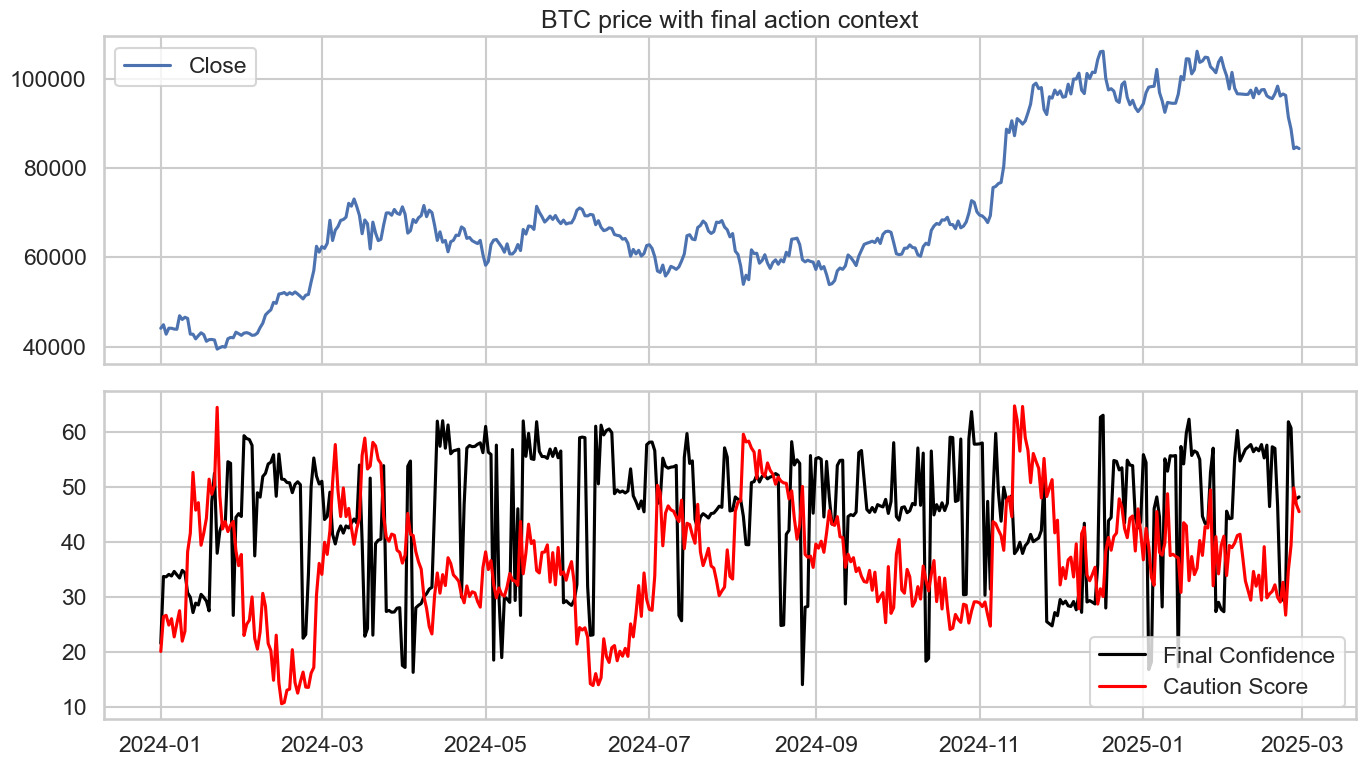

In [7]:
latest = fused_data.iloc[-1]

decision_card = pd.Series({
    'Asset': asset_label,
    'Base Direction': latest['BaseDirection'],
    'Technical Score': latest['TechnicalScore'],
    'Technical Confidence': latest['TechnicalConfidence'],
    'Polymarket Net Sentiment': pm_aggregate['pm_net_sentiment'],
    'Polymarket Weighted Sentiment': pm_aggregate['pm_liquidity_weighted_sentiment'],
    'Polymarket Market Quality': pm_aggregate['pm_market_quality'],
    'Caution Score': latest['CautionScore'],
    'Risk Zone': latest['RiskZone'],
    'Final Confidence': latest['FinalConfidence'],
    'Recommended Position Size': latest['PositionSize'],
    'Final Action': latest['FinalAction'],
}).to_frame('Value')
display(decision_card)

if not tagged_polymarket.empty:
    explanation = tagged_polymarket[['question', 'direction', 'theme', 'mid', 'spread', 'days_to_resolution']].head(10)
    display(explanation)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(fused_data.index, fused_data['Close'], label='Close')
axes[0].set_title(f'{asset_label} price with final action context')
axes[0].legend()
axes[1].plot(fused_data.index, fused_data['FinalConfidence'], label='Final Confidence', color='black')
axes[1].plot(fused_data.index, fused_data['CautionScore'], label='Caution Score', color='red')
axes[1].legend()
plt.tight_layout()
plt.show()


## 9. Scenario Analysis

This section asks how the trade changes if Polymarket sentiment or market structure shifts. It is useful for understanding whether the setup is robust or fragile.


,Scenario,FinalConfidence,AdjustedCaution,FinalAction,PositionSize
0,Base,48.221486,45.539056,Short,0.25
1,PM sentiment improves,49.471486,45.539056,Short,0.25
2,PM sentiment weakens,46.971486,45.539056,Short,0.25
3,Spreads widen,45.221486,57.539056,Short,0.25
4,Event risk rises,46.221486,53.539056,Short,0.25
5,Better PM and lower event risk,51.221486,39.539056,Short,0.25


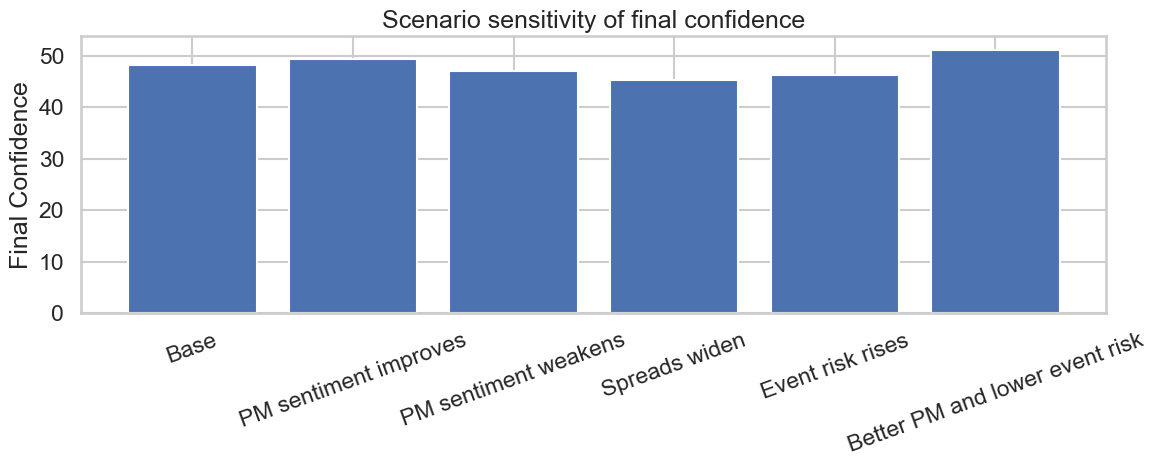

In [8]:
def scenario_adjusted_confidence(latest_row, pm_aggregate, sentiment_shift=0.0, spread_multiplier=1.0, event_risk_shift=0.0):
    pm_sent = float(pm_aggregate.get('pm_liquidity_weighted_sentiment', 0) or 0) + sentiment_shift
    pm_sent = float(np.clip(pm_sent, -1, 1))
    pm_quality = float(pm_aggregate.get('pm_market_quality', 0) or 0)
    conflict = float(pm_aggregate.get('pm_dispersion', 0) or 0)

    adjusted_caution = np.clip(
        latest_row['CautionScore']
        + 20 * (spread_multiplier - 1)
        + 20 * event_risk_shift,
        0,
        100,
    )
    confidence = np.clip(
        0.55 * latest_row['TechnicalConfidence']
        + 25 * np.clip(0.5 + 0.5 * pm_sent, 0, 1)
        + 10 * pm_quality
        - 10 * conflict
        - 0.25 * adjusted_caution,
        0,
        100,
    )
    if confidence < confidence_trade_threshold or adjusted_caution >= avoid_threshold:
        action = 'No Trade'
        size = 0.0
    else:
        action = latest_row['BaseDirection'] if latest_row['BaseDirection'] in {'Long', 'Short'} else 'No Trade'
        size = 0.25 if confidence < 55 else 0.50 if confidence < 70 else 0.75 if confidence < 85 else 1.0
    return {'FinalConfidence': confidence, 'AdjustedCaution': adjusted_caution, 'FinalAction': action, 'PositionSize': size}


scenarios = pd.DataFrame([
    {'Scenario': 'Base', **scenario_adjusted_confidence(latest, pm_aggregate, 0.0, 1.0, 0.0)},
    {'Scenario': 'PM sentiment improves', **scenario_adjusted_confidence(latest, pm_aggregate, 0.10, 1.0, 0.0)},
    {'Scenario': 'PM sentiment weakens', **scenario_adjusted_confidence(latest, pm_aggregate, -0.10, 1.0, 0.0)},
    {'Scenario': 'Spreads widen', **scenario_adjusted_confidence(latest, pm_aggregate, 0.0, 1.6, 0.0)},
    {'Scenario': 'Event risk rises', **scenario_adjusted_confidence(latest, pm_aggregate, 0.0, 1.0, 0.4)},
    {'Scenario': 'Better PM and lower event risk', **scenario_adjusted_confidence(latest, pm_aggregate, 0.12, 0.9, -0.2)},
])
display(scenarios)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(scenarios['Scenario'], scenarios['FinalConfidence'])
ax.set_title('Scenario sensitivity of final confidence')
ax.set_ylabel('Final Confidence')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


## 10. Backtest Comparison

This section compares three variants:

1. Technical-only
2. Technical plus Polymarket confirmation filter
3. Technical plus Polymarket confidence-based sizing

The purpose is to test whether Polymarket actually improves the trading process.


,Variant,Total Return,Max Drawdown,Hit Rate,Average Exposure,Trades / Turnover Proxy
0,Technical Only,0.061340,-0.347832,0.390588,0.795294,73.00
1,Technical + PM Filter,0.544965,-0.154630,0.192941,0.383529,32.00
2,Technical + PM Sizing,0.109652,-0.119519,0.374118,0.254706,36.25


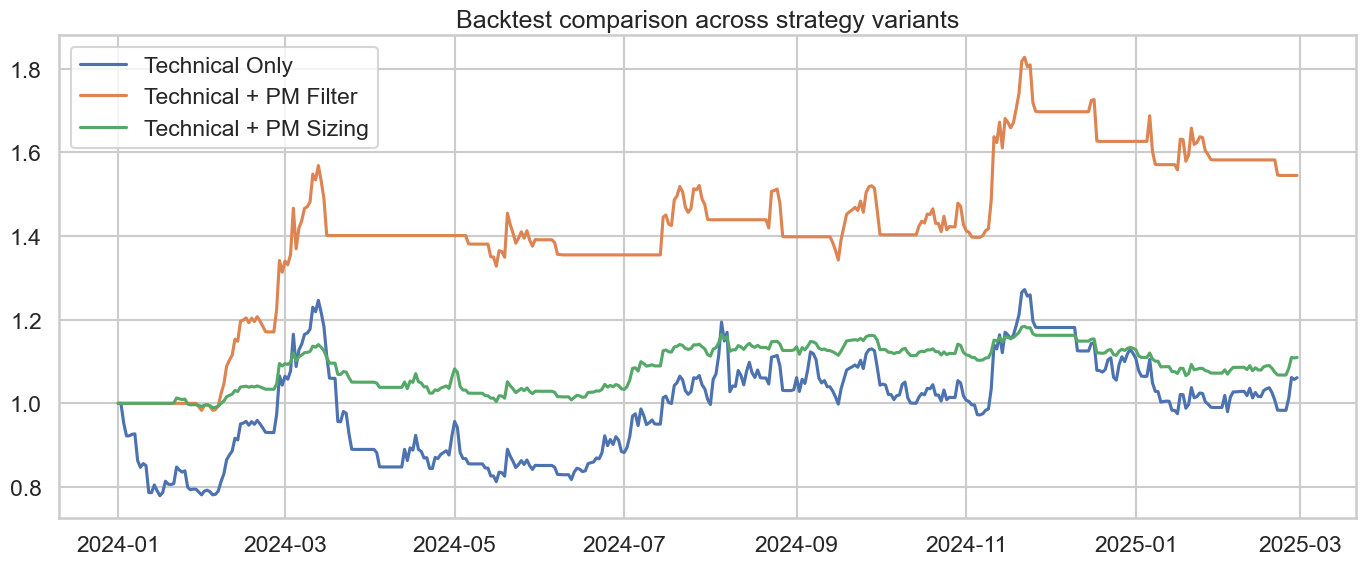

In [9]:
def direction_to_position(direction):
    return {'Long': 1, 'Short': -1, 'Flat': 0, 'No Trade': 0}.get(direction, 0)


def run_backtest_variants(fused_df, fee_bps=5):
    bt = fused_df.copy()
    bt['BasePosition'] = bt['BaseDirection'].map(direction_to_position).fillna(0)
    bt['Return_1D'] = bt['Return_1D'].fillna(0)

    bt['TechOnlyPosition'] = bt['BasePosition'].shift(1).fillna(0)
    bt['TechOnlyTurnover'] = bt['TechOnlyPosition'].diff().abs().fillna(bt['TechOnlyPosition'].abs())
    bt['TechOnlyReturn'] = bt['TechOnlyPosition'] * bt['Return_1D'] - bt['TechOnlyTurnover'] * (fee_bps / 10000)
    bt['TechOnlyEquity'] = (1 + bt['TechOnlyReturn']).cumprod()

    bt['PMFilteredSignal'] = np.where((bt['PMAgreement'] == 1) & (bt['FinalConfidence'] >= confidence_trade_threshold), bt['BasePosition'], 0)
    bt['PMFilteredPosition'] = bt['PMFilteredSignal'].shift(1).fillna(0)
    bt['PMFilteredTurnover'] = bt['PMFilteredPosition'].diff().abs().fillna(bt['PMFilteredPosition'].abs())
    bt['PMFilteredReturn'] = bt['PMFilteredPosition'] * bt['Return_1D'] - bt['PMFilteredTurnover'] * (fee_bps / 10000)
    bt['PMFilteredEquity'] = (1 + bt['PMFilteredReturn']).cumprod()

    bt['PMSizedSignal'] = bt['BasePosition'] * bt['PositionSize']
    bt['PMSizedPosition'] = bt['PMSizedSignal'].shift(1).fillna(0)
    bt['PMSizedTurnover'] = bt['PMSizedPosition'].diff().abs().fillna(bt['PMSizedPosition'].abs())
    bt['PMSizedReturn'] = bt['PMSizedPosition'] * bt['Return_1D'] - bt['PMSizedTurnover'] * (fee_bps / 10000)
    bt['PMSizedEquity'] = (1 + bt['PMSizedReturn']).cumprod()
    return bt


def summarize_backtests(bt):
    rows = []
    for label, ret_col, eq_col, pos_col in [
        ('Technical Only', 'TechOnlyReturn', 'TechOnlyEquity', 'TechOnlyPosition'),
        ('Technical + PM Filter', 'PMFilteredReturn', 'PMFilteredEquity', 'PMFilteredPosition'),
        ('Technical + PM Sizing', 'PMSizedReturn', 'PMSizedEquity', 'PMSizedPosition'),
    ]:
        equity = bt[eq_col]
        returns = bt[ret_col]
        drawdown = equity / equity.cummax() - 1
        rows.append({
            'Variant': label,
            'Total Return': equity.iloc[-1] - 1,
            'Max Drawdown': drawdown.min(),
            'Hit Rate': (returns > 0).mean(),
            'Average Exposure': bt[pos_col].abs().mean(),
            'Trades / Turnover Proxy': bt[pos_col].diff().abs().sum(),
        })
    return pd.DataFrame(rows)


backtest_variants = run_backtest_variants(fused_data)
backtest_summary = summarize_backtests(backtest_variants)
display(backtest_summary)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(backtest_variants.index, backtest_variants['TechOnlyEquity'], label='Technical Only')
ax.plot(backtest_variants.index, backtest_variants['PMFilteredEquity'], label='Technical + PM Filter')
ax.plot(backtest_variants.index, backtest_variants['PMSizedEquity'], label='Technical + PM Sizing')
ax.set_title('Backtest comparison across strategy variants')
ax.legend()
plt.tight_layout()
plt.show()
